In [1]:
# siibra is a Python library that provides programmatic access to human brain atlases—especially the Julich-Brain Atlas—enabling 
#querying, downloading, and visualization of brain regions, maps, and connectivity data from the EBRAINS platform. this cell 
#we just testing different functions of siibra
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.


In [5]:
#An instance table in Python refers to a table (usually a list of dictionaries or a DataFrame) 
#that contains data extracted from instances (objects) of a custom class.
# siibra uses instance tables not only for atlases, but also for parcellations
# (`siibra.parcellations`), reference spaces (`siibra.spaces`) or feature
# modalities (`siibra.modalities`), as will be shown in later code examples.
#
# Objects stored in a siibra instance table can be accessed in
# different ways:
#
#  1. In "list-style": by iterating over all objects or using the index operator "[]"
#  2. By fuzzy keyword matching via the get() function or index operator
#  3. By tab-completion of their "keys"
siibra.atlases.keys    

['MULTILEVEL_HUMAN_ATLAS',
 'PRERELEASE_MARMOSET_ATLAS',
 'MONKEY_ATLAS',
 'ALLEN_MOUSE_COMMON_COORDINATE_FRAMEWORK_V3',
 'WAXHOLM_SPACE_ATLAS_OF_THE_SPRAGUE_DAWLEY_RAT_BRAIN']

In [6]:
# The keys can be used to select atlas object by autocompletion
# when you hit <TAB>. This makes it convenient to find the right name
# in an interactive shell.
atlas = siibra.atlases.MULTILEVEL_HUMAN_ATLAS
atlas

<Atlas(identifier='juelich/iav/atlas/v1.0.0/1', name='Multilevel Human Atlas', species='Homo sapiens')>

In [7]:
# We can also select an atlas by specifying the key as a string
# in the get() method:
siibra.atlases.get("MULTILEVEL HUMAN ATLAS")

<Atlas(identifier='juelich/iav/atlas/v1.0.0/1', name='Multilevel Human Atlas', species='Homo sapiens')>

In [8]:
# More importantly, we can use an arbitrary set of words
# matching the name or key of atlas. This is usually the simplest way
# to select from a Registry. It will fail if no unique match is found.
siibra.atlases.get('human')

<Atlas(identifier='juelich/iav/atlas/v1.0.0/1', name='Multilevel Human Atlas', species='Homo sapiens')>

In [13]:
siibra.atlases[0]
siibra.atlases['human']

<Atlas(identifier='juelich/iav/atlas/v1.0.0/1', name='Multilevel Human Atlas', species='Homo sapiens')>

In [15]:
# The instance table can list the keys of all parcellations predefined in `siibra`.
# Note that this includes parcellations for all supported atlases.
siibra.parcellations.keys

Loading preconfigured Parcellation instances: 100%|███████████████████████████████| 28/28 [00:11<00:00,  2.39Parcellation/s]


['DEEP_WHITE_MATTER_FIBRE_BUNDLES',
 'SUPERFICIAL_FIBRE_BUNDLES',
 'CORTICAL_LAYER_SEGMENTATION_OF_THE_BIGBRAIN_MODEL',
 'DIFUMO_ATLAS_1024_DIMENSIONS',
 'DIFUMO_ATLAS_128_DIMENSIONS',
 'DIFUMO_ATLAS_256_DIMENSIONS',
 'DIFUMO_ATLAS_512_DIMENSIONS',
 'DIFUMO_ATLAS_64_DIMENSIONS',
 'DESIKAN_KILLIANY_ATLAS_2006',
 'HARVARDOXFORD_CORT_MAXPROB_THR0',
 'HARVARDOXFORD_CORT_MAXPROB_THR25',
 'ISOCORTEX_SEGMENTATION',
 'JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V1_18',
 'JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V2_9',
 'JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_0_3',
 'JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1',
 'MARMOSET_NENCKI_MONASH_ATLAS_2020',
 'MARSATLAS_CORTICAL_PARCELLATION_MODEL',
 'MEBRAINS_POPULATION_BASED_MONKEY_PARCELLATION',
 'ALLEN_MOUSE_COMMON_COORDINATE_FRAMEWORK_V3_2015',
 'ALLEN_MOUSE_COMMON_COORDINATE_FRAMEWORK_V3_2017',
 'WAXHOLM_SPACE_ATLAS_OF_THE_SPRAGUE_DAWLEY_RAT_BRAIN_V1_01',
 'WAXHOLM_SPACE_ATLAS_OF_THE_SPRAGUE_DAWLEY_RAT_BRAIN_V2',
 'WAXHOLM_SPACE_ATLAS_OF_THE_SPRAGUE_DAWLEY_RA

In [16]:
# Fetching an object works in the same way as for `siibra.atlases` (see :ref:`atlases`)
julich_brain = siibra.parcellations.get('julich')

[siibra:INFO] Multiple elements matched the specification 'julich' - the first in order was chosen: Julich-Brain Cytoarchitectonic Atlas (v3.1)


In [19]:
# just look at a few metadata fields:
print("Name:    ", julich_brain.name)
print("Id:      ", julich_brain.id)
print("Modality:", julich_brain.modality)
print()
print(julich_brain.description)
print()
for p in julich_brain.publications:
    print(p['citation'])

Name:     Julich-Brain Cytoarchitectonic Atlas (v3.1)
Id:       minds/core/parcellationatlas/v1.0.0/94c1125b-b87e-45e4-901c-00daee7f2579-310
Modality: cytoarchitecture

The Julich-Brain Atlas (RRID:SCR_023277) presents in this dataset cytoarchitectonicmaps in several coordinate spaces, such as MNI Colin 27, MNI ICBM 152, andFreeSurfer. These maps originate from peer-reviewed probability maps (PMs) that defineboth cortical and subcortical brain regions. Notably, these probability maps account forthe brain's inter-individual variability by analyzing data from ten post- mortem samples.For a whole-brain parcellation, the available probability maps are combined into amaximum probability map (MPM) by considering for each voxel the probability of allcytoarchitectonic brain regions, and determining the most probable assignment.Continuously evolving, the atlas is regularly updated with new areas. Furthermore, itstands as a reference atlas for the Human Brain Project and is deeply embedded withi

In [20]:
# The region hierarchy is a tree structure. Its default representation is a
# string of the tree.
julich_brain.render_tree()

Julich-Brain Cytoarchitectonic Atlas (v3.1)
├── telencephalon
│   ├── cerebral nuclei
│   │   ├── basal ganglia
│   │   │   ├── ventral pallidum
│   │   │   │   ╰── VP (Ventral Pallidum)
│   │   │   │       ├── VP (Ventral Pallidum) right
│   │   │   │       ╰── VP (Ventral Pallidum) left
│   │   │   ╰── ventral striatum
│   │   │       ├── FuCd (Ventral Striatum, Fundus of Caudate Nucleus)
│   │   │       │   ├── FuCd (Ventral Striatum, Fundus of Caudate Nucleus) right
│   │   │       │   ╰── FuCd (Ventral Striatum, Fundus of Caudate Nucleus) left
│   │   │       ├── AcbM (Ventral Striatum, Medial Accumbens)
│   │   │       │   ├── AcbM (Ventral Striatum, Medial Accumbens) right
│   │   │       │   ╰── AcbM (Ventral Striatum, Medial Accumbens) left
│   │   │       ├── AcbL (Ventral Striatum, Lateral Accumbens)
│   │   │       │   ├── AcbL (Ventral Striatum, Lateral Accumbens) right
│   │   │       │   ╰── AcbL (Ventral Striatum, Lateral Accumbens) left
│   │   │       ╰── FuP (Ventral

In [21]:
# Each node is a `Region` object, including the root node.
# We can iterate all regions in a parcellation
[region.name for region in julich_brain]

['Julich-Brain Cytoarchitectonic Atlas (v3.1)',
 'telencephalon',
 'cerebral nuclei',
 'basal ganglia',
 'ventral pallidum',
 'VP (Ventral Pallidum)',
 'VP (Ventral Pallidum) right',
 'VP (Ventral Pallidum) left',
 'ventral striatum',
 'FuCd (Ventral Striatum, Fundus of Caudate Nucleus)',
 'FuCd (Ventral Striatum, Fundus of Caudate Nucleus) right',
 'FuCd (Ventral Striatum, Fundus of Caudate Nucleus) left',
 'AcbM (Ventral Striatum, Medial Accumbens)',
 'AcbM (Ventral Striatum, Medial Accumbens) right',
 'AcbM (Ventral Striatum, Medial Accumbens) left',
 'AcbL (Ventral Striatum, Lateral Accumbens)',
 'AcbL (Ventral Striatum, Lateral Accumbens) right',
 'AcbL (Ventral Striatum, Lateral Accumbens) left',
 'FuP (Ventral Striatum, Fundus of Putamen)',
 'FuP (Ventral Striatum, Fundus of Putamen) right',
 'FuP (Ventral Striatum, Fundus of Putamen) left',
 'basal forebrain',
 'sublenticular basal forebrain',
 'Ch 4 (Basal Forebrain)',
 'Ch 4 (Basal Forebrain) right',
 'Ch 4 (Basal Forebrain) 

In [22]:
# We can iterate the brain divisions in the parcellation
[region.name for region in julich_brain.children]

['telencephalon', 'mesencephalon', 'metencephalon', 'diencephalon']

In [23]:
# We can also iterate only the leaves of the tree
[region.name for region in julich_brain.leaves]

['VP (Ventral Pallidum) right',
 'VP (Ventral Pallidum) left',
 'FuCd (Ventral Striatum, Fundus of Caudate Nucleus) right',
 'FuCd (Ventral Striatum, Fundus of Caudate Nucleus) left',
 'AcbM (Ventral Striatum, Medial Accumbens) right',
 'AcbM (Ventral Striatum, Medial Accumbens) left',
 'AcbL (Ventral Striatum, Lateral Accumbens) right',
 'AcbL (Ventral Striatum, Lateral Accumbens) left',
 'FuP (Ventral Striatum, Fundus of Putamen) right',
 'FuP (Ventral Striatum, Fundus of Putamen) left',
 'Ch 4 (Basal Forebrain) right',
 'Ch 4 (Basal Forebrain) left',
 'BST (Basal Forebrain, Bed Nucleus) right',
 'BST (Basal Forebrain, Bed Nucleus) left',
 'Ch 123 (Basal Forebrain) right',
 'Ch 123 (Basal Forebrain) left',
 'CM.AAA (Amygdala) right',
 'CM.Ce (Amygdala) right',
 'CM.Me (Amygdala) right',
 'CM.AAA (Amygdala) left',
 'CM.Ce (Amygdala) left',
 'CM.Me (Amygdala) left',
 'LB.Bl (Amygdala) right',
 'LB.Bm (Amygdala) right',
 'LB.Pl (Amygdala) right',
 'LB.La (Amygdala) right',
 'LB.Bl (Amyg

In [26]:
# The most basic way is to search for all regions matching a particular string:
julich_brain.find("STN (Subthalamus) right")

[<Region(identifier='minds/core/parcellationatlas/v1.0.0/94c1125b-b87e-45e4-901c-00daee7f2579-310_STN_SUBTHALAMUS_RIGHT', name='STN (Subthalamus) right', species='Homo sapiens')>]

In [25]:
# You can filter the children and querying the root node by:
julich_brain.find('v1', filter_children=True)

[<Region(identifier='minds/core/parcellationatlas/v1.0.0/94c1125b-b87e-45e4-901c-00daee7f2579-310_AREA_HOC1_V1_17_CALCS', name='Area hOc1 (V1, 17, CalcS)', species='Homo sapiens')>]

In [27]:
space = atlas.spaces.get("Thalamus")
print(space.name)

NameError: name 'atlas' is not defined

In [51]:
STN_R = siibra.get_region("JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1", "STN (Subthalamus) right")
print(STN_R)

STN (Subthalamus) right


In [52]:
print(STN_R.spaces)

InstanceTable:
 - MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC
 - MNI_COLIN_27


In [53]:
print(STN_R.name)

STN (Subthalamus) right


In [69]:
space = STN_R.spaces.get("MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC")
print(space)

MNI 152 ICBM 2009c Nonlinear Asymmetric


In [60]:
from pprint import pprint
props = STN_R.spatial_props(space=space)
pprint(props)

[ComponentSpatialProperties(centroid=<Point((11.890274314214452, -10.643391521197003, -8.077306733167077), space='minds/core/referencespace/v1.0.0/7f39f7be-445b-47c0-9791-e971c0b6d992', sigma_mm=0.0)>,
                            volume=np.float64(401.0))]


In [62]:
dir(STN_R)

['LICENSE',
 '_ASSIGNMENT_CACHE',
 '_CACHED_MATCHES',
 '_GETMASK_CACHE',
 '_GETMASK_CACHE_MAX_ENTRIES',
 '_NodeMixin__attach',
 '_NodeMixin__check_children',
 '_NodeMixin__check_loop',
 '_NodeMixin__children',
 '_NodeMixin__children_or_empty',
 '_NodeMixin__detach',
 '_NodeMixin__parent',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_accepted_flags',
 '_configuration_folder',
 '_description',
 '_id',
 '_path',
 '_post_attach',
 '_post_attach_children',
 '_post_detach',
 '_post_detach_children',
 '_pre_attach',
 '_pre_attach_children',
 '_pre_detach

In [75]:
STN_map = STN_R.get_regional_map(space, maptype="statistical")
print(STN_map)

Volume siibra-map-v0.0.1_mni152-jba31_207-continuous - volume 381 in space MNI 152 ICBM 2009c Nonlinear Asymmetric


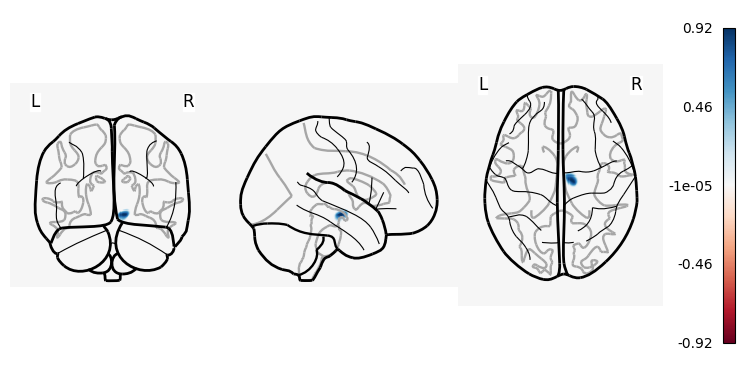

In [85]:
plotting.plot_glass_brain(STN_map.fetch(), alpha=1, cmap="RdBu", symmetric_cbar=True)

[siibra:INFO] 'gene expressions' decoded as feature type/s: ['GeneExpressions'].


https://doi.org/10.1038%2Fnature11405


<Axes: title={'center': 'Gene expression STN (Subthalamus) right'}, xlabel='gene', ylabel='expression level'>

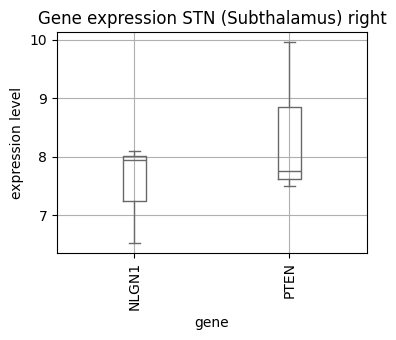

In [82]:
#https://siibra-python.readthedocs.io/en/latest/examples/tutorials/2025-paper-fig3.html#sphx-glr-examples-tutorials-2025-paper-fig3-py
genes = ["PTEN", "NLGN1"]
gene_expressions = siibra.features.get(STN_R, "gene expressions", gene=genes)
print("\n".join(gene_expressions[0].urls))
fig, axs = plt.subplots(1, 1, figsize=(4, 3.5))
gene_expressions[0].plot(ax=axs)

In [98]:
dir(STN_map)

['IMAGE_FORMATS',
 'MESH_FORMATS',
 'SUPPORTED_FORMATS',
 '_ASSIGNMENT_CACHE',
 '_FETCH_CACHE',
 '_FETCH_CACHE_MAX_ENTRIES',
 '_FORMAT_LOOKUP',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_boundingbox',
 '_name',
 '_points_inside',
 '_providers',
 '_space_spec',
 'assign',
 'compute_spatial_props',
 'datasets',
 'draw_samples',
 'evaluate_points',
 'fetch',
 'fetch_connected_components',
 'find_peaks',
 'formats',
 'fragments',
 'get_boundingbox',
 'intersection',
 'intersects',
 'name',
 'providers',
 'provides_image',
 'provides_mesh',
 'space',
 'species',


In [102]:
STN_map.provides_mesh

False

In [2]:
STN_R = siibra.get_region("JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1", "STN (Subthalamus) left")
space = STN_R.spaces.get("MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC")
STN_map = STN_R.get_regional_map(space, maptype="statistical")

Loading preconfigured Map instances: 100%|█████████████████████████████████████████████| 59/59 [00:00<00:00, 59.56Map/s]
[siibra:WARNING] Map registry contains multiple classes: Map, SparseMap


In [3]:
NIfTI_STN_R = STN_map.fetch()
type(NIfTI_STN_R)

nibabel.nifti1.Nifti1Image

In [4]:
# Get voxel data as a numpy array
STN_R_data = NIfTI_STN_R.get_fdata()

In [5]:
# Basic stats
print("Number of voxels:", STN_R_data.size)
print("Min probability:", STN_R_data.min())
print("Max probability:", STN_R_data.max())
print("Mean probability:", STN_R_data.mean())
print("Standard deviation:", STN_R_data.std())

Number of voxels: 8530021
Min probability: 0.0
Max probability: 0.8974618315696716
Mean probability: 3.8260651421661814e-05
Standard deviation: 0.004315333140739117


In [6]:
print(STN_R_data.shape)

(193, 229, 193)


In [7]:
STN_R_data.nonzero()

(array([78, 78, 78, ..., 91, 91, 91], shape=(1383,)),
 array([113, 113, 114, ..., 124, 124, 124], shape=(1383,)),
 array([69, 70, 68, ..., 66, 67, 68], shape=(1383,)))

In [8]:
# Assuming STN_R_data is a 3D NumPy array
nonzero_indices = np.argwhere(STN_R_data > 0)             # Shape: (N, 3)
nonzero_values = STN_R_data[STN_R_data > 0]               # Shape: (N,)

# Combine indices and values into a single array: (x, y, z, value)
nonzero_voxels = np.hstack((nonzero_indices, nonzero_values[:, np.newaxis]))

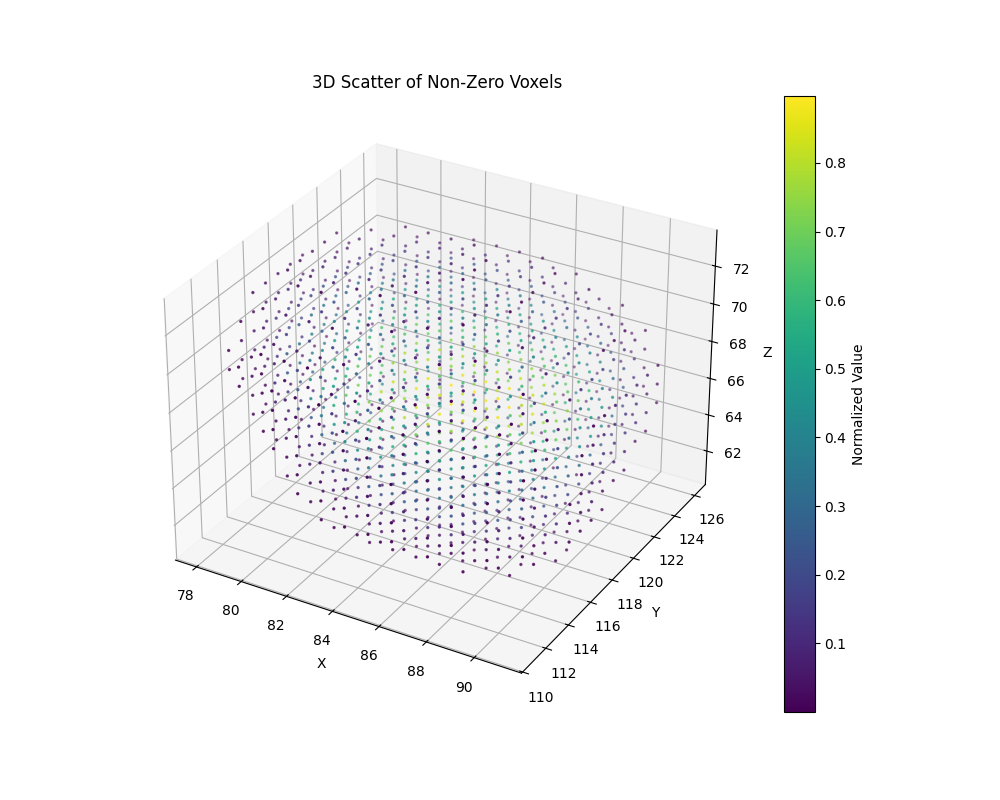

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting
%matplotlib inline
%matplotlib widget

# Step 1: Get coordinates and values of non-zero voxels
nonzero_indices = np.argwhere(STN_R_data > 0)
nonzero_values = STN_R_data[STN_R_data > 0]

# Step 2: Plot as 3D scatter
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Split coordinates
x, y, z = nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]

# Normalize values for color mapping
#norm_values = (nonzero_values - nonzero_values.min()) / (nonzero_values.ptp())

# Scatter plot
sc = ax.scatter(x, y, z, c=nonzero_values, cmap='viridis', s=2)

# Color bar
plt.colorbar(sc, ax=ax, label='Normalized Value')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter of Non-Zero Voxels')

plt.show()


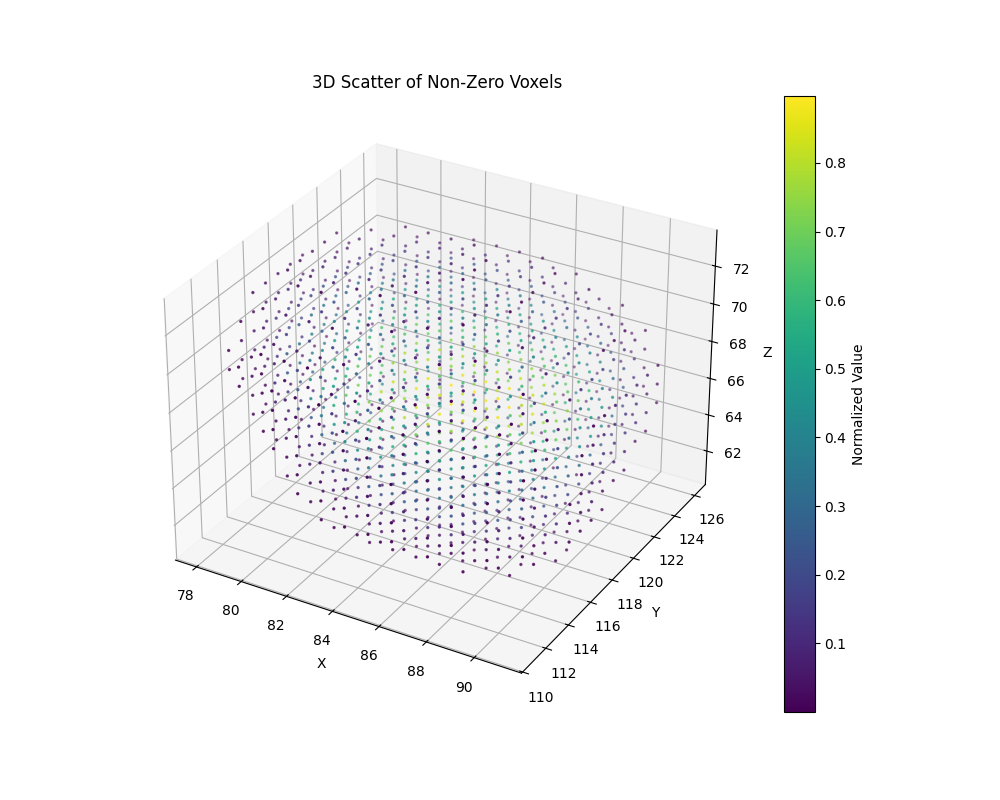

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting
%matplotlib inline
%matplotlib widget

# Step 1: Get coordinates and values of non-zero voxels
nonzero_indices = np.argwhere(STN_R_data > 0)
nonzero_values = STN_R_data[STN_R_data > 0]

# Step 2: Plot as 3D scatter
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Split coordinates
x, y, z = nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]

# Normalize values for color mapping
#norm_values = (nonzero_values - nonzero_values.min()) / (nonzero_values.ptp())

# Scatter plot
sc = ax.scatter(x, y, z, c=nonzero_values, cmap='viridis', s=2)

# Color bar
plt.colorbar(sc, ax=ax, label='Normalized Value')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter of Non-Zero Voxels')

plt.show()
